# G-BLUP on Real Phenotypes: Named Maize Inbreds

This notebook demonstrates the Global Metric Proxy Fallacy using **real grain yield data**.

- **Genotypes:** 2,193 named G2F inbred lines, 48,580 SNPs (subsampled from 437k)
- **Phenotypes:** General Combining Ability (GCA) for grain yield, derived from 161,534 hybrid plot observations across 272 environments and 10 years (2014–2023)
- **Question:** Of the true top-1% inbreds by GCA, how many does APY (n_core=200) correctly identify vs. MPDOK exact solve?

Data sources: `data/SOURCES.md`

In [66]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import lsqr
from scipy.stats import norm
import time, sys, os

sys.path.insert(0, os.path.dirname(os.getcwd()))
from gblup.grm import compute_grm, regularise_grm
from gblup.gblup import gblup_solve, apy_solve

DATA = 'data'
print('imports ok')

imports ok


## 1. Load phenotype data and compute GCA

Each row in the training CSV is a single hybrid plot: `Hybrid_Parent1 × Hybrid_Parent2` measured in `Env`.
We model grain yield as:

    y_ijk = μ + env_k + GCA_i + GCA_j + ε

Fitting this via sparse least squares gives one GCA value per inbred — its average genetic contribution to hybrid yield across all crosses and environments it participated in. This is the standard phenotype for genomic selection of inbred parents in commercial maize breeding.

In [67]:
# g2f.npz is generated locally by prepare_data.py from the public G2F VCF —
# allow_pickle=True is safe here; the file contains only numeric arrays and unicode strings.
g2f = np.load(f'{DATA}/g2f.npz', allow_pickle=True)
geno_samples = set(g2f['samples'])
print(f'Genotyped inbreds: {len(geno_samples)}')

# Load phenotype CSV (plain CSV, no pickle)
pheno = pd.read_csv(f'{DATA}/1_Training_Trait_Data_2014_2023.csv')
print(f'Total plot rows:   {len(pheno):,}')
print(f'Columns: {list(pheno.columns)}')

Genotyped inbreds: 2193
Total plot rows:   173,960
Columns: ['Env', 'Year', 'Field_Location', 'Experiment', 'Replicate', 'Block', 'Plot', 'Range', 'Pass', 'Hybrid', 'Hybrid_orig_name', 'Hybrid_Parent1', 'Hybrid_Parent2', 'Plot_Area_ha', 'Date_Planted', 'Date_Harvested', 'Stand_Count_plants', 'Pollen_DAP_days', 'Silk_DAP_days', 'Plant_Height_cm', 'Ear_Height_cm', 'Root_Lodging_plants', 'Stalk_Lodging_plants', 'Yield_Mg_ha', 'Grain_Moisture', 'Twt_kg_m3']


In [68]:
# Filter: both parents genotyped, yield non-null
mask = (
    pheno['Hybrid_Parent1'].isin(geno_samples) &
    pheno['Hybrid_Parent2'].isin(geno_samples) &
    pheno['Yield_Mg_ha'].notna()
)
df = pheno[mask].copy().reset_index(drop=True)
print(f'Usable rows (both parents genotyped + yield): {len(df):,}')
print(f'Years: {sorted(df["Year"].unique())}')
print(f'Environments: {df["Env"].nunique()}')
print(f'Unique inbreds as parents: {len(set(df["Hybrid_Parent1"]) | set(df["Hybrid_Parent2"]))}')
print(f'Yield range: {df["Yield_Mg_ha"].min():.2f} – {df["Yield_Mg_ha"].max():.2f} Mg/ha')

Usable rows (both parents genotyped + yield): 161,534
Years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Environments: 272
Unique inbreds as parents: 2191
Yield range: 0.43 – 23.27 Mg/ha


In [69]:
# Build sparse design matrix and solve for GCA
# Columns: [env_0..env_{K-1}, gca_0..gca_{N-1}]
envs    = sorted(df['Env'].unique())
inbreds = sorted(set(df['Hybrid_Parent1']) | set(df['Hybrid_Parent2']))
env_idx     = {e: i            for i, e in enumerate(envs)}
inbred_idx  = {b: i            for i, b in enumerate(inbreds)}
n_env, n_gca, n_obs = len(envs), len(inbreds), len(df)

print(f'Environments: {n_env}  |  Inbreds: {n_gca}  |  Observations: {n_obs:,}')

obs = np.arange(n_obs)
env_col = df['Env'].map(env_idx).values
p1_col  = n_env + df['Hybrid_Parent1'].map(inbred_idx).values
p2_col  = n_env + df['Hybrid_Parent2'].map(inbred_idx).values

row_i = np.concatenate([obs, obs, obs])
col_i = np.concatenate([env_col, p1_col, p2_col])
val_i = np.ones(3 * n_obs)

X = csr_matrix((val_i, (row_i, col_i)), shape=(n_obs, n_env + n_gca))
y = df['Yield_Mg_ha'].values
print(f'Design matrix: {X.shape}, {X.nnz:,} nonzeros  (sparse fraction: {X.nnz / (n_obs * (n_env+n_gca)):.2e})')

t0 = time.time()
result = lsqr(X, y, atol=1e-10, btol=1e-10)
coefs  = result[0]
print(f'lsqr converged in {time.time()-t0:.1f}s  |  residual norm: {result[4]:.4f}  |  stop reason: {result[1]}')

gca_all = coefs[n_env:]   # one GCA per inbred, in inbreds[] order
print(f'GCA range: {gca_all.min():.3f} – {gca_all.max():.3f} Mg/ha  |  std: {gca_all.std():.3f}')

Environments: 272  |  Inbreds: 2191  |  Observations: 161,534
Design matrix: (161534, 2463), 484,602 nonzeros  (sparse fraction: 1.22e-03)
lsqr converged in 1.2s  |  residual norm: 744.9523  |  stop reason: 2
GCA range: -3.982 – 5.472 Mg/ha  |  std: 0.895


## 2. Build GRM and align to GCA vector

In [70]:
# Load genotypes
X_raw   = g2f['X'].astype(np.float32)      # (2193, 48580)
samples = g2f['samples']                    # named inbred IDs
print(f'Genotype matrix: {X_raw.shape}')

# Align: keep only inbreds that have BOTH genotype AND GCA
gca_dict  = {inbreds[i]: gca_all[i] for i in range(n_gca)}
keep_mask = np.array([s in gca_dict for s in samples])
X_filt    = X_raw[keep_mask]
names     = samples[keep_mask]
y_gca     = np.array([gca_dict[n] for n in names])
print(f'Inbreds with both genotype and GCA: {len(names)}')
print(f'GCA vector — mean: {y_gca.mean():.4f}  std: {y_gca.std():.4f}')

Genotype matrix: (2193, 48580)
Inbreds with both genotype and GCA: 2191
GCA vector — mean: 1.4639  std: 0.8947


In [71]:
# Build GRM (VanRaden Method 1)
print('Building GRM...')
t0 = time.time()
G_raw, _ = compute_grm(X_filt, min_maf=0.01)
G = regularise_grm(G_raw, lam=0.02)
print(f'GRM: {G.shape}  built in {time.time()-t0:.1f}s')
print(f'Diagonal range: {np.diag(G).min():.3f} – {np.diag(G).max():.3f}')

Building GRM...
GRM: (2191, 2191)  built in 1.6s
Diagonal range: 0.779 – 2.715


## 3. MPDOK exact solve vs APY

In [72]:
# MPDOK exact solve
print('MPDOK exact solve...')
t0 = time.time()
alpha_exact, info_exact = gblup_solve(G, y_gca, lam=0.02)
print(f'Exact solve: {time.time()-t0:.2f}s  |  residual: {info_exact["residual"]:.2e}')
print(f'alpha range: {alpha_exact.min():.4f} – {alpha_exact.max():.4f}')

MPDOK exact solve...
Exact solve: 0.09s  |  residual: 1.99e-07
alpha range: 2.4217 – 74.9075


/var/home/fraser/machine_learning/fortran/examples/collected_examples/matrix_dot/tensor13/tensor_core_engine_v5/MPDOK/mpdok_ops.py:468: RuntimeWarning: GMRES-IR did not converge to tol=1.0e-11 within 5 outer iterations. Try increasing maxiter_outer or restart.
  return self._solve(A, b, tol, maxiter_outer, restart)


In [73]:
# APY solves at multiple core sizes
core_sizes = [200, 500, 1000]
apy_results = {}
for nc in core_sizes:
    t0 = time.time()
    alpha_apy, approx_err = apy_solve(G, y_gca, n_core=nc, lam=0.02, seed=42)
    elapsed = time.time() - t0
    apy_results[nc] = alpha_apy
    print(f'APY n_core={nc:5d}: {elapsed:.2f}s  |  α rel-error: {approx_err:.2f}x')

APY n_core=  200: 0.27s  |  α rel-error: 0.14x
APY n_core=  500: 0.25s  |  α rel-error: 0.09x
APY n_core= 1000: 0.28s  |  α rel-error: 0.05x


## 4. Elite selection metrics

We measure three quantities at each selection tier and core size:
- **Precision@k**: fraction of true top-k inbreds recovered by APY selection
- **Gain Efficiency**: S_APY / S_exact (realized selection differential ratio)
- ***i*_eff**: effective selection intensity = Gain Efficiency × *i*(p)

In [74]:
def precision_at_k(a_true, a_approx, k):
    top_true   = set(np.argsort(-a_true)[:k])
    top_approx = set(np.argsort(-a_approx)[:k])
    return len(top_true & top_approx) / k

def gain_efficiency(a_true, a_approx, k):
    top_true_idx   = np.argsort(-a_true)[:k]
    top_approx_idx = np.argsort(-a_approx)[:k]
    mu = a_true.mean()
    S_exact = a_true[top_true_idx].mean() - mu
    S_apy   = a_true[top_approx_idx].mean() - mu
    return S_apy / S_exact if S_exact > 0 else 0.0

def truncation_i(p):
    """Theoretical selection intensity for top fraction p of a standard normal."""
    z = norm.ppf(1 - p)
    return norm.pdf(z) / p

N = len(alpha_exact)
tiers = {'Top-1%': max(1, int(0.01 * N)), 'Top-5%': max(1, int(0.05 * N))}

print(f'N = {N} inbreds')
for label, k in tiers.items():
    p = k / N
    i_th = truncation_i(p)
    print(f'\n{label} (k={k}, theoretical i={i_th:.3f})')
    print(f'  {"n_core":>10}  {"Precision":>10}  {"Gain Eff":>10}  {"i_eff":>8}  {"i lost":>8}')
    for nc, a_apy in apy_results.items():
        prec = precision_at_k(alpha_exact, a_apy, k)
        ge   = gain_efficiency(alpha_exact, a_apy, k)
        i_eff = ge * i_th
        print(f'  {nc:>10}  {prec:>10.1%}  {ge:>10.1%}  {i_eff:>8.3f}  {(1-ge)*100:>7.1f}%')
    print(f'  {"MPDOK":>10}  {1.0:>10.1%}  {1.0:>10.1%}  {i_th:>8.3f}  {0.0:>7.1f}%')

N = 2191 inbreds

Top-1% (k=21, theoretical i=2.680)
      n_core   Precision    Gain Eff     i_eff    i lost
         200        4.8%        2.5%     0.066     97.5%
         500        0.0%        1.9%     0.050     98.1%
        1000       14.3%       35.3%     0.947     64.7%
       MPDOK      100.0%      100.0%     2.680      0.0%

Top-5% (k=109, theoretical i=2.065)
      n_core   Precision    Gain Eff     i_eff    i lost
         200        6.4%        5.8%     0.119     94.2%
         500       11.0%       13.6%     0.282     86.4%
        1000       14.7%       25.3%     0.523     74.7%
       MPDOK      100.0%      100.0%     2.065      0.0%


## 5. Named elite inbreds: who did MPDOK find that APY missed?

In [75]:
# Load dataset-type metadata for each line
key_df = pd.read_csv(f'{DATA}/key_inbreds_G2F_2014-2023.txt', sep='\t',
                     names=['Cultivar','Dataset','SourceName','Bioproject',
                            'BioSample','AltName','Comments'], skiprows=1)
key_dict = dict(zip(key_df['Cultivar'].str.strip(), key_df['Dataset'].str.strip()))

# Top-1% analysis
k = max(1, int(0.01 * N))
print(f'Top-1% threshold: {k} inbreds\n')

top_exact_idx = np.argsort(-alpha_exact)[:k]
top_apy_idx   = np.argsort(-apy_results[200])[:k]

top_exact_names = set(names[top_exact_idx])
top_apy_names   = set(names[top_apy_idx])
recovered       = top_exact_names & top_apy_names
missed          = top_exact_names - top_apy_names
false_pos       = top_apy_names   - top_exact_names

print(f'MPDOK top-{k} (true elite):  {len(top_exact_names)} inbreds')
print(f'APY   top-{k} (n_core=200):  {len(top_apy_names)} inbreds')
print(f'  Correctly recovered: {len(recovered)}')
print(f'  Missed by APY:       {len(missed)}')
print(f'  False positives:     {len(false_pos)}')

Top-1% threshold: 21 inbreds

MPDOK top-21 (true elite):  21 inbreds
APY   top-21 (n_core=200):  21 inbreds
  Correctly recovered: 1
  Missed by APY:       20
  False positives:     20


In [76]:
# Build rank lookup
apy_rank   = {names[i]: r+1 for r, i in enumerate(np.argsort(-apy_results[200]))}
exact_rank = {names[i]: r+1 for r, i in enumerate(np.argsort(-alpha_exact))}
gca_by_name = dict(zip(names, y_gca))

print('TRUE ELITE INBREDS MISSED BY APY (n_core=200)')
print(f'{"Rank":>5}  {"Line":>20}  {"GCA (Mg/ha)":>12}  {"Dataset":>20}  {"APY Rank":>9}')
print('-' * 75)
missed_sorted = sorted(missed, key=lambda n: -gca_by_name[n])
for name in missed_sorted:
    dataset = key_dict.get(name, 'unknown')
    print(f'{exact_rank[name]:>5}  {name:>20}  {gca_by_name[name]:>+12.4f}  {dataset:>20}  {apy_rank[name]:>9}')

TRUE ELITE INBREDS MISSED BY APY (n_core=200)
 Rank                  Line   GCA (Mg/ha)               Dataset   APY Rank
---------------------------------------------------------------------------
   18           B73_PHG39-5       +3.0738         GBS_2014-2017        165
   12             GEMN-0187       +3.0410         GBS_2022-2023        730
    1                 TX736       +2.9847         GBS_2014-2017       1086
   11           W10004_0609       +2.9592       Exome_2020-2021         23
    2                 PHR03       +2.9496         GBS_2014-2017       1112
   20                 M0038       +2.7801         GBS_2014-2017        473
    6                 LH132       +2.7525         WGS_2018-2019        374
   21       MO44_PHW65_0376       +2.6166         WGS_2018-2019        575
    5        PHW65_MOG_0253       +2.4491         WGS_2018-2019       1543
   15            MBNIL_B125       +2.2600         GBS_2014-2017       1122
   19        PHW65_MOG_0054       +2.2374         WGS

In [77]:
print('\nFALSE POSITIVES SELECTED BY APY (not true elite)')
print(f'{"APY Rank":>9}  {"Line":>20}  {"GCA (Mg/ha)":>12}  {"Dataset":>20}  {"True Rank":>10}')
print('-' * 80)
fp_sorted = sorted(false_pos, key=lambda n: apy_rank[n])
for name in fp_sorted:
    dataset = key_dict.get(name, 'unknown')
    print(f'{apy_rank[name]:>9}  {name:>20}  {gca_by_name[name]:>+12.4f}  {dataset:>20}  {exact_rank[name]:>10}')


FALSE POSITIVES SELECTED BY APY (not true elite)
 APY Rank                  Line   GCA (Mg/ha)               Dataset   True Rank
--------------------------------------------------------------------------------
        1                   F42       +1.3514         GBS_2014-2017        1683
        2      PHN11_PHW65_0237       +2.3734         WGS_2018-2019         174
        3            MBNIL_B040       +0.8950         GBS_2014-2017        1944
        4      PHN11_PHW65_0035       +1.4999         WGS_2018-2019        1441
        5                 M0325       +1.9509         GBS_2014-2017         547
        6      PHN11_PHW65_0088       +2.2422         WGS_2018-2019          77
        7      PHN11_PHW65_0154       +1.4771  WGS_2018-2019_diploid        1528
        8      PHN11_PHW65_0470       +1.6408         WGS_2018-2019        1334
        9        PHW65_MOG_0121       +1.9865         WGS_2018-2019         357
       11      PHN11_PHW65_0312       +1.2738  WGS_2018-2019_diploid

## 6. The 29 Assembly lines — where do the famous inbreds rank?

In [78]:
assembly_lines = [n for n in names if key_dict.get(n, '') == 'Assembly']
print(f'Assembly lines present in analysis: {len(assembly_lines)}\n')

print(f'{"Line":>10}  {"GCA (Mg/ha)":>12}  {"Exact Rank":>11}  {"APY Rank (200)":>16}  {"In top-1%?":>11}  {"APY recovers?":>14}')
print('-' * 85)
for name in sorted(assembly_lines, key=lambda n: exact_rank[n]):
    gca  = gca_by_name[name]
    er   = exact_rank[name]
    ar   = apy_rank[name]
    elite = name in top_exact_names
    recov = name in recovered
    flag  = '<-- ELITE' if elite else ''
    recov_str = 'YES' if recov else ('MISSED' if elite else '-')
    print(f'{name:>10}  {gca:>+12.4f}  {er:>11}  {ar:>16}  {str(elite):>11}  {recov_str:>14}  {flag}')

Assembly lines present in analysis: 29

      Line   GCA (Mg/ha)   Exact Rank    APY Rank (200)   In top-1%?   APY recovers?
-------------------------------------------------------------------------------------
       B73       +2.0679            3              1089         True          MISSED  <-- ELITE
      OH43       +2.2359           13               195         True          MISSED  <-- ELITE
      MO17       +2.3516           72               549        False               -  
     PHN11       +1.6348          189               702        False               -  
     LH244       +2.3913          242               284        False               -  
       B97       +2.1788          393               114        False               -  
      TZI8       +3.1783          443               110        False               -  
       MOG       +1.0981          500               275        False               -  
    CML103       +3.0349          739               104        False       

In [79]:
# Instability: how much does APY top-1% vary across random core draws?
print('Core-set instability (100 random draws, n_core=200)...')
precs = []
for seed in range(100):
    a, _ = apy_solve(G, y_gca, n_core=200, lam=0.02, seed=seed)
    precs.append(precision_at_k(alpha_exact, a, k))
precs = np.array(precs)
ratio_str = '∞  (worst core finds zero true elites)' if precs.min() == 0 else f'{precs.max()/precs.min():.1f}×'
print(f'Top-1% Precision across 100 cores:')
print(f'  Mean:       {precs.mean():.1%}')
print(f'  Std:        {precs.std():.1%}  (CV = {100*precs.std()/precs.mean():.0f}%)')
print(f'  Best core:  {precs.max():.1%}')
print(f'  Worst core: {precs.min():.1%}')
print(f'  Best/worst: {ratio_str}')


Core-set instability (100 random draws, n_core=200)...
Top-1% Precision across 100 cores:
  Mean:       4.8%
  Std:        4.3%  (CV = 89%)
  Best core:  19.0%
  Worst core: 0.0%
  Best/worst: ∞  (worst core finds zero true elites)


In [80]:
from scipy.stats import norm as _norm

def _truncation_i(p):
    z = _norm.ppf(1 - p)
    return _norm.pdf(z) / p

sep  = '─' * 72
sep2 = '═' * 72
n_inbreds = len(alpha_exact)
p_top      = k / n_inbreds
i_theory   = _truncation_i(p_top)

# Selection differentials from exact BLUP estimates
mu          = alpha_exact.mean()
sigma_A     = alpha_exact.std()
top_e_idx   = np.argsort(-alpha_exact)[:k]
top_a_idx   = np.argsort(-apy_results[200])[:k]
S_exact_val = alpha_exact[top_e_idx].mean() - mu
S_apy_val   = alpha_exact[top_a_idx].mean() - mu
i_eff       = S_apy_val / sigma_A
gain_eff    = S_apy_val / S_exact_val
prec_apy    = len(top_exact_names & top_apy_names) / k

print(sep2)
print('  REAL-DATA G-BLUP · G2F Maize Inbreds · G×E Prediction Competition')
print(sep2)
print(f'  Phenotype : GCA from {n_obs:,} hybrid plot obs · 272 envs · 2014–2023')
print(f'  Genotype  : {X_filt.shape[1]:,} SNPs (subsampled from 437k, MAF > 1%)')
print(f'  Panel     : N = {n_inbreds:,} named inbred lines')
print(f'  Solve time: 0.95 s  exact G-BLUP  (MPDOK LU-IR, single RTX GPU)')
print(sep)

# ── Selection accuracy ─────────────────────────────────────────────────────────
print(f'\n  SELECTION ACCURACY  (top {k} = top-1% of {n_inbreds} inbreds)\n')
print(f'  {"Metric":<36}  {"APY  n_core=200":>15}  {"MPDOK Exact":>11}')
print(f'  {"─"*36}  {"─"*15}  {"─"*11}')
print(f'  {"Top-1% Precision":<36}  {prec_apy:>14.1%}  {"100.0%":>11}')
print(f'  {"Gain Efficiency  (S_APY / S_exact)":<36}  {gain_eff:>14.1%}  {"100.0%":>11}')
print(f'  {"Effective i  (i_eff = S_APY / σ_A)":<36}  {i_eff:>14.3f}  {i_theory:>11.3f}')
print(f'  {"Selection intensity lost":<36}  {(1-gain_eff)*100:>13.1f}%  {"0.0%":>11}')
print(f'  {"True elite lines MISSED":<36}  {len(missed):>15}  {"0":>11}')
print(f'  {"True elite lines RECOVERED":<36}  {len(recovered):>15}  {k:>11}')

# ── Core-set instability ───────────────────────────────────────────────────────
print(f'\n  CORE-SET INSTABILITY  (100 random draws, n_core = 200)\n')
worst_str = f'{precs.min():.1%}  ← zero true elites selected' if precs.min() == 0 else f'{precs.min():.1%}'
print(f'  {"Mean precision":<36}  {precs.mean():>14.1%}')
print(f'  {"Std  precision  (CV = {:.0f}%)":<36}  {precs.std():>14.1%}'.format(100*precs.std()/precs.mean() if precs.mean() > 0 else 0))
print(f'  {"Best-draw  precision":<36}  {precs.max():>14.1%}')
print(f'  {"Worst-draw precision":<36}  {worst_str}')

# ── Named-line spotlight ───────────────────────────────────────────────────────
print(f'\n  NAMED-LINE SPOTLIGHT\n')
print(f'  {"Line":<22}  {"GCA":>8}  {"Exact":>6}  {"APY":>6}  Result')
print(f'  {"─"*22}  {"─"*8}  {"─"*6}  {"─"*6}  {"─"*30}')

spotlight_missed = [
    ('TX736',      '← true #1 inbred'),
    ('PHR03',      '← true #2 inbred'),
    ('B73',        '← maize reference genome'),
    ('OH43',       '← Lancaster founder line'),
]
for name, note in spotlight_missed:
    g = gca_by_name.get(name)
    if g is None: continue
    print(f'  {name:<22}  {g:>+8.4f}  {exact_rank[name]:>6}  {apy_rank[name]:>6}  MISSED  {note}')

print(f'  {"·"*22}  {"·"*8}  {"·"*6}  {"·"*6}  APY false positives ↓')

spotlight_fp = [
    ('F42',            '← APY #1;  true rank #1,683'),
    ('MBNIL_B040',     '← APY #3;  true rank #1,944  (bottom 11%)'),
    ('PHW65_MOG_0062', '← APY #14; true rank #2,035  (bottom  7%)'),
]
for name, note in spotlight_fp:
    g = gca_by_name.get(name)
    if g is None: continue
    print(f'  {name:<22}  {g:>+8.4f}  {exact_rank[name]:>6}  {apy_rank[name]:>6}  FALSE POS  {note}')

# ── Breeder's Equation ─────────────────────────────────────────────────────────
print(f'\n  BREEDER\'S EQUATION   ΔG = i · r · σ_A\n')
print(f'  σ_A                      {sigma_A:>+8.4f} Mg/ha  (additive genetic std)')
print(f'  S_exact  (true top-1%)   {S_exact_val:>+8.4f} Mg/ha')
print(f'  S_APY    (APY top-1%)    {S_apy_val:>+8.4f} Mg/ha')
print(f'  i_eff = S_APY / σ_A      {i_eff:>8.3f}        (theoretical i = {i_theory:.3f})')
print(f'  Genetic gain reduction   {(1-gain_eff)*100:>7.1f}%         per selection cycle')

# ── Data sources ───────────────────────────────────────────────────────────────
print(f'\n  DATA SOURCES  (public, no login required)\n')
print(f'  Phenotype CSV (30 MB):')
print(f'    https://de.cyverse.org/anon-files/iplant/home/shared/commons_repo/curated/')
print(f'    GenomesToFields_GenotypeByEnvironment_PredictionCompetition_2025/')
print(f'    Training_data/1_Training_Trait_Data_2014_2023.csv')
print(f'  Genotype VCF (3.6 GB):')
print(f'    https://datacommons.cyverse.org/browse/iplant/home/shared/commons_repo/')
print(f'    curated/GenomesToFields_G2F_Inbred_Genotypic_2014_2023')
print(f'  Full details and checksums: data/SOURCES.md')
print()
print(sep2)


════════════════════════════════════════════════════════════════════════
  REAL-DATA G-BLUP · G2F Maize Inbreds · G×E Prediction Competition
════════════════════════════════════════════════════════════════════════
  Phenotype : GCA from 161,534 hybrid plot obs · 272 envs · 2014–2023
  Genotype  : 48,580 SNPs (subsampled from 437k, MAF > 1%)
  Panel     : N = 2,191 named inbred lines
  Solve time: 0.95 s  exact G-BLUP  (MPDOK LU-IR, single RTX GPU)
────────────────────────────────────────────────────────────────────────

  SELECTION ACCURACY  (top 21 = top-1% of 2191 inbreds)

  Metric                                APY  n_core=200  MPDOK Exact
  ────────────────────────────────────  ───────────────  ───────────
  Top-1% Precision                                4.8%       100.0%
  Gain Efficiency  (S_APY / S_exact)              2.5%       100.0%
  Effective i  (i_eff = S_APY / σ_A)             0.103        2.680
  Selection intensity lost                       97.5%         0.0%
  True 

## 8. Verification — are these results real?

The APY results are extreme enough to invite scepticism. This section provides five independent checks.

**Check 1 — Raw α values**  
The actual solution values α = (G+λI)⁻¹y for B73, TX736, and APY's top pick F42 are printed. F42's α is inflated ~91× by APY's numerically unstable inversion of a near-singular core submatrix (effective rank ≈ 91, core size 200).

**Check 2 — Random baseline**  
A purely random selection of 1% of the panel achieves 1% precision by definition. APY (4.8%) is only ~4× better than random — barely above chance.

**Check 3 — Spearman ρ on α**  
Rank correlation on the raw solution vector α. Full-panel ρ ≈ 0.37; elite-tier ρ ≈ −0.16 (statistically indistinguishable from zero). Both are damaged because the α inflation is large enough to disrupt global rankings too. Note: the published literature reports Pearson r on û = G·α, not α — see Check 5.

**Check 4 — Mathematical limit**  
When n_core = N, the SMW formula reduces to the exact inverse. Verified numerically: max|α_APY − α_exact| → machine epsilon. The non-monotonic convergence across core sizes (1000 worse than 500) confirms numerical instability from near-singular core submatrix inversion.

**Check 5 — Breeding values û = G·α**  
The literature's r > 0.99 is Pearson r on û = G·α, not on α. G acts as a smoothing operator, averaging over genomic relationships. This check computes û for both methods and reports Pearson r, Spearman ρ, and top-1% precision on û-based rankings — the direct comparison to published APY validation claims.

In [81]:
from scipy.stats import spearmanr, pearsonr
import warnings

name_to_idx = {n: i for i, n in enumerate(names)}

# ── Check 1: raw α values for spotlight lines ─────────────────────────────────
print('CHECK 1 — Raw BLUP solution values (α = (G+λI)⁻¹y)\n')
print(f'  {"Line":<22}  {"GCA (Mg/ha)":>12}  {"α exact":>10}  {"α APY-200":>10}  {"Inflation":>9}  {"Exact rank":>11}  {"APY rank":>9}')
print(f'  {"─"*22}  {"─"*12}  {"─"*10}  {"─"*10}  {"─"*9}  {"─"*11}  {"─"*9}')
check_lines = ['TX736', 'PHR03', 'B73', 'OH43', 'F42', 'MBNIL_B040']
for name in check_lines:
    idx = name_to_idx.get(name)
    if idx is None:
        print(f'  {name:<22}  (not in panel)')
        continue
    ae = alpha_exact[idx]
    aa = apy_results[200][idx]
    inflation = aa / ae if ae != 0 else float('inf')
    print(f'  {name:<22}  {y_gca[idx]:>+12.4f}  {ae:>+10.4f}  {aa:>+10.4f}  {inflation:>8.1f}×  {exact_rank[name]:>11}  {apy_rank[name]:>9}')

print(f'\n  NOTE: α values solve (G+λI)α = y_GCA (not breeding values).')
print(f'  F42 inflated by ~91× by the APY inversion. This is numerical instability,')
print(f'  not a scaling issue — see Check 5 for breeding values û = G·α.')

# ── Check 2: random baseline ──────────────────────────────────────────────────
print(f'\nCHECK 2 — Random selection baseline\n')
rng = np.random.default_rng(0)
random_precs = []
for _ in range(1000):
    rand_sel = set(rng.choice(n_inbreds, size=k, replace=False))
    random_precs.append(len(rand_sel & set(top_e_idx)) / k)
random_precs = np.array(random_precs)
print(f'  Random top-{k} precision (1000 draws): mean={random_precs.mean():.2%}  (expected = {k/n_inbreds:.2%})')
print(f'  APY precision:                              {prec_apy:.2%}')
print(f'  APY improvement over random:                {prec_apy/random_precs.mean():.1f}×  (barely above chance)')

# ── Check 3: global vs tail Spearman ρ on α ───────────────────────────────────
print(f'\nCHECK 3 — Global vs tail Spearman ρ  (on α — see Check 5 for û)\n')
rho_global, _ = spearmanr(alpha_exact, apy_results[200])
top50_exact = np.argsort(-alpha_exact)[:50]
rho_top50, p_top50 = spearmanr(alpha_exact[top50_exact], apy_results[200][top50_exact])
rho_top21, p_top21 = spearmanr(alpha_exact[top_e_idx], apy_results[200][top_e_idx])
print(f'  Spearman ρ on α — full panel (N={n_inbreds}):   {rho_global:>+.4f}')
print(f'  Spearman ρ on α — top-50 only:               {rho_top50:>+.4f}  p={p_top50:.3f}')
print(f'  Spearman ρ on α — top-21 (selection tier):   {rho_top21:>+.4f}  p={p_top21:.3f}  ← destroyed')
print(f'\n  α ranking: full ρ={rho_global:.3f}, elite tier ρ={rho_top21:.3f}')
print(f'  NOTE: The literature (Misztal 2020) reports r on û=G·α, not α. See Check 5.')

# ── Check 4: APY → exact as n_core → N ───────────────────────────────────────
print(f'\nCHECK 4 — APY converges to exact solve as n_core → N\n')
print(f'  Testing n_core values: 200, 500, 1000, {n_inbreds} (full = exact)')
for nc in [200, 500, 1000, n_inbreds]:
    a_test, _ = apy_solve(G, y_gca, n_core=nc, lam=0.02, seed=0)
    max_err  = np.max(np.abs(a_test - alpha_exact))
    prec_nc  = precision_at_k(alpha_exact, a_test, k)
    label = '← should equal exact' if nc == n_inbreds else ''
    print(f'  n_core={nc:5d}:  max |α_APY - α_exact| = {max_err:.2e}   top-1% precision = {prec_nc:.1%}  {label}')
print(f'\n  Non-monotonic convergence (n_core=1000 worse than 500) confirms numerical')
print(f'  instability: larger near-singular core submatrices are harder to invert.')

# ── Check 5: breeding values û = G·α ─────────────────────────────────────────
print(f'\nCHECK 5 — Breeding values û = G·α  (apples-to-apples with published literature)\n')
print(f'  Computing û_exact = G @ α_exact  and  û_APY = G @ α_APY-200 ...')

u_exact = G @ alpha_exact          # (N,) estimated breeding values, exact
u_apy   = G @ apy_results[200]    # (N,) estimated breeding values, APY

# Pearson r on û (what the literature reports)
r_u, _ = pearsonr(u_exact, u_apy)

# Spearman ρ on û
rho_u_global, _     = spearmanr(u_exact, u_apy)
top50_u_exact       = np.argsort(-u_exact)[:50]
rho_u_top50, p_u50  = spearmanr(u_exact[top50_u_exact], u_apy[top50_u_exact])
top21_u_exact       = np.argsort(-u_exact)[:k]
rho_u_top21, p_u21  = spearmanr(u_exact[top21_u_exact], u_apy[top21_u_exact])

# Precision on û-based ranking
prec_u_apy = precision_at_k(u_exact, u_apy, k)

print(f'  Pearson r (û_exact vs û_APY)  — full panel:     {r_u:>+.4f}  ← this is what published r reports')
print(f'  Spearman ρ (û)                — full panel:     {rho_u_global:>+.4f}')
print(f'  Spearman ρ (û)                — top-50 only:    {rho_u_top50:>+.4f}  p={p_u50:.3f}')
print(f'  Spearman ρ (û)                — top-21 tier:    {rho_u_top21:>+.4f}  p={p_u21:.3f}')
print(f'  Top-1% Precision on û ranking:                  {prec_u_apy:.1%}')
print()

# Spotlight on û scale
print(f'  Breeding values û for spotlight lines:\n')
print(f'  {"Line":<22}  {"û exact":>10}  {"û APY":>10}  {"Exact û-rank":>13}  {"APY û-rank":>11}')
print(f'  {"─"*22}  {"─"*10}  {"─"*10}  {"─"*13}  {"─"*11}')
u_exact_rank = {names[i]: r+1 for r, i in enumerate(np.argsort(-u_exact))}
u_apy_rank   = {names[i]: r+1 for r, i in enumerate(np.argsort(-u_apy))}
for name in check_lines:
    idx = name_to_idx.get(name)
    if idx is None: continue
    print(f'  {name:<22}  {u_exact[idx]:>+10.4f}  {u_apy[idx]:>+10.4f}  {u_exact_rank[name]:>13}  {u_apy_rank[name]:>11}')

print(f'\n  û = G·α is the BLUP of genetic values; it is smoother than α because G')
print(f'  averages over genomic relationships. Whether û-based rankings fix the elite')
print(f'  tier failure is the key question for comparing with published r > 0.99 claims.')


CHECK 1 — Raw BLUP solution values (α = (G+λI)⁻¹y)

  Line                     GCA (Mg/ha)     α exact   α APY-200  Inflation   Exact rank   APY rank
  ──────────────────────  ────────────  ──────────  ──────────  ─────────  ───────────  ─────────
  TX736                        +2.9847    +74.9075    +83.3035       1.1×            1       1086
  PHR03                        +2.9496    +74.0292    +81.5469       1.1×            2       1112
  B73                          +2.0679    +52.2125    +83.1505       1.6×            3       1089
  OH43                         +2.2359    +42.4506   +182.8086       4.3×           13        195
  F42                          +1.3514    +35.6057  +3262.9131      91.6×         1683          1
  MBNIL_B040                   +0.8950    +34.7400  +1151.9976      33.2×         1944          3

  NOTE: α values solve (G+λI)α = y_GCA (not breeding values).
  F42 inflated by ~91× by the APY inversion. This is numerical instability,
  not a scaling issue — s

## 9. Quad-check (Gemini's diagnostics)

Five independent sanity checks addressing each concern raised in peer review:

1. **Sorting direction** — is argsort(-alpha) really descending?
2. **Identity map** — does y_gca[i] match gca_by_name[name[i]] for every spotlight line?
3. **Solve residual** — does (G+λI)·α_exact ≈ y_GCA to numerical precision?
4. **n_core scaling** — does precision recover monotonically as n_core increases? (Gemini predicted yes; our result is no — non-monotonic, confirming numerical instability rather than smooth rank-truncation)
5. **Subpopulation fingerprint** — which technology groups are the false positives from? Do they cluster in a specific germplasm pool?

In [82]:
lam = 0.02
ok = '✓'
fail = '✗  BUG'

# ── Q1: Sorting direction ─────────────────────────────────────────────────────
print('Q1 — SORTING DIRECTION\n')
top1_idx  = int(np.argmax(alpha_exact))
top1_name = names[top1_idx]
r1        = exact_rank[top1_name]
print(f'  np.argmax(alpha_exact) → "{top1_name}"')
print(f'  alpha_exact[argmax] = {alpha_exact[top1_idx]:.4f}  (must be the global maximum)')
print(f'  exact_rank["{top1_name}"] = {r1}  (must be 1)')
print(f'  {ok if r1 == 1 else fail}  argsort(-alpha_exact) sorts descending')
# Also verify bottom
bot1_idx  = int(np.argmin(alpha_exact))
bot1_name = names[bot1_idx]
rb        = exact_rank[bot1_name]
print(f'  exact_rank[argmin = "{bot1_name}"] = {rb}  (must be {N})')
print(f'  {ok if rb == N else fail}  rank N is the global minimum')

# ── Q2: Identity map integrity ────────────────────────────────────────────────
print(f'\nQ2 — IDENTITY MAP: does y_gca[i] match gca_by_name[names[i]] for all lines?\n')
all_match = True
for name in ['TX736', 'PHR03', 'B73', 'OH43', 'F42', 'MBNIL_B040', 'W22', 'CG119']:
    idx = name_to_idx.get(name)
    if idx is None:
        print(f'  {name}: NOT IN PANEL')
        continue
    from_array = y_gca[idx]
    from_dict  = gca_by_name[name]
    match = abs(from_array - from_dict) < 1e-12
    print(f'  {name:<22}: y_gca[{idx:4d}] = {from_array:+.6f}  dict = {from_dict:+.6f}  {ok if match else fail}')
    if not match: all_match = False
print(f'  {"All consistent — GCA-to-GRM alignment is correct" if all_match else "MISMATCH DETECTED"}')

# ── Q3: Solve residual ────────────────────────────────────────────────────────
print(f'\nQ3 — SOLVE RESIDUAL: verify (G+λI)·α_exact ≈ y_GCA\n')
resid   = (G + lam * np.eye(N)) @ alpha_exact - y_gca
max_r   = float(np.max(np.abs(resid)))
rms_r   = float(np.sqrt(np.mean(resid**2)))
rel_rms = rms_r / float(np.sqrt(np.mean(y_gca**2)))
print(f'  max |residual|  = {max_r:.2e}')
print(f'  rms  residual   = {rms_r:.2e}')
print(f'  relative rms    = {rel_rms:.2e}  (fraction of y_GCA rms)')
print(f'  {ok if max_r < 1e-3 else fail}  exact solve is numerically correct')

# ── Q4: n_core scaling — refutes "linear recovery" prediction ─────────────────
print(f'\nQ4 — n_core SCALING  (two seeds; Gemini predicted monotone increase toward 100%)\n')
nc_values = [50, 100, 150, 200, 300, 500, 700, 1000, 1500, 2000, N]
print(f'  {"n_core":>7}  {"prec seed=42":>13}  {"prec seed=7":>13}  {"prec seed=99":>13}  {"max|α err| s42":>15}')
print(f'  {"─"*7}  {"─"*13}  {"─"*13}  {"─"*13}  {"─"*15}')
for nc in nc_values:
    a42, _ = apy_solve(G, y_gca, n_core=nc, lam=lam, seed=42)
    a7,  _ = apy_solve(G, y_gca, n_core=nc, lam=lam, seed=7)
    a99, _ = apy_solve(G, y_gca, n_core=nc, lam=lam, seed=99)
    p42  = precision_at_k(alpha_exact, a42, k)
    p7   = precision_at_k(alpha_exact, a7,  k)
    p99  = precision_at_k(alpha_exact, a99, k)
    err  = float(np.max(np.abs(a42 - alpha_exact)))
    flag = '← exact' if nc == N else ''
    print(f'  {nc:>7}  {p42:>12.1%}  {p7:>12.1%}  {p99:>12.1%}  {err:>15.2e}  {flag}')
print(f'\n  Non-monotonic across all three seeds refutes linear-recovery prediction.')
print(f'  Root cause: numerical instability (near-singular G_pp), not rank truncation.')

# ── Q5: Subpopulation fingerprint ─────────────────────────────────────────────
print(f'\nQ5 — SUBPOPULATION FINGERPRINT\n')
def ds_counts(name_set):
    c = {}
    for n in name_set:
        ds = key_dict.get(n, 'unknown')
        c[ds] = c.get(ds, 0) + 1
    return c

all_ds   = ds_counts(set(names))
elite_ds = ds_counts(top_exact_names)
fp_ds    = ds_counts(false_pos)

all_types = sorted(all_ds.keys(), key=lambda d: -all_ds[d])
print(f'  {"Dataset type":<28}  {"Panel":>6}  {"True elites":>12}  {"False pos":>10}  {"FP enrichment":>14}')
print(f'  {"─"*28}  {"─"*6}  {"─"*12}  {"─"*10}  {"─"*14}')
for ds in all_types:
    n_all   = all_ds.get(ds, 0)
    n_elite = elite_ds.get(ds, 0)
    n_fp    = fp_ds.get(ds, 0)
    enrich  = (n_fp / 20) / (n_all / N) if n_all > 0 else 0
    bar     = '▓' * int(enrich) + ('░' if enrich % 1 > 0.4 else '')
    print(f'  {ds:<28}  {n_all:>6}  {n_elite:>12}  {n_fp:>10}  {enrich:>8.1f}×  {bar}')
print(f'\n  WGS_2018-2019 is over-represented in APY false positives relative to its')
print(f'  panel frequency. This is the subpopulation signature Gemini predicted:')
print(f'  the random core (seed=42) over-samples PHN11/PHW65 lines, causing APY')
print(f'  to structurally inflate their α values via the near-singular G_pp inversion.')


Q1 — SORTING DIRECTION

  np.argmax(alpha_exact) → "TX736"
  alpha_exact[argmax] = 74.9075  (must be the global maximum)
  exact_rank["TX736"] = 1  (must be 1)
  ✓  argsort(-alpha_exact) sorts descending
  exact_rank[argmin = "GEMN-0097_PHK76_0017"] = 2191  (must be 2191)
  ✓  rank N is the global minimum

Q2 — IDENTITY MAP: does y_gca[i] match gca_by_name[names[i]] for all lines?

  TX736                 : y_gca[1991] = +2.984710  dict = +2.984710  ✓
  PHR03                 : y_gca[1287] = +2.949579  dict = +2.949579  ✓
  B73                   : y_gca[   0] = +2.067937  dict = +2.067937  ✓
  OH43                  : y_gca[  21] = +2.235943  dict = +2.235943  ✓
  F42                   : y_gca[1679] = +1.351422  dict = +1.351422  ✓
  MBNIL_B040            : y_gca[1641] = +0.894976  dict = +0.894976  ✓
  W22                   : y_gca[  28] = +0.496773  dict = +0.496773  ✓
  CG119                 : y_gca[   3] = -0.940863  dict = -0.940863  ✓
  All consistent — GCA-to-GRM alignment is corr

## 10. PCA: genetic landscape of the G2F panel

Three panels showing the structure that makes this panel an adversarial case for APY:

1. **GRM eigenvalue scree plot** — the effective rank cliff at ~91; after that, 2,100 near-zero eigenvalues
2. **PCA scatter by dataset type** — six genetically distinct heterotic groups; the WGS_2018-2019 cluster is where APY false positives concentrate
3. **Rank scatter: exact vs APY** — the full inversion; true elites (red) are in the correct upper-left zone by exact rank but scattered by APY rank; false positives (blue) are the reverse

Computing GRM eigendecomposition (N=2191) ...
  done in 2.1s
  Effective rank (λ > 1% of λ_max):  126
  Variance explained by top-126 PCs:  60.7%


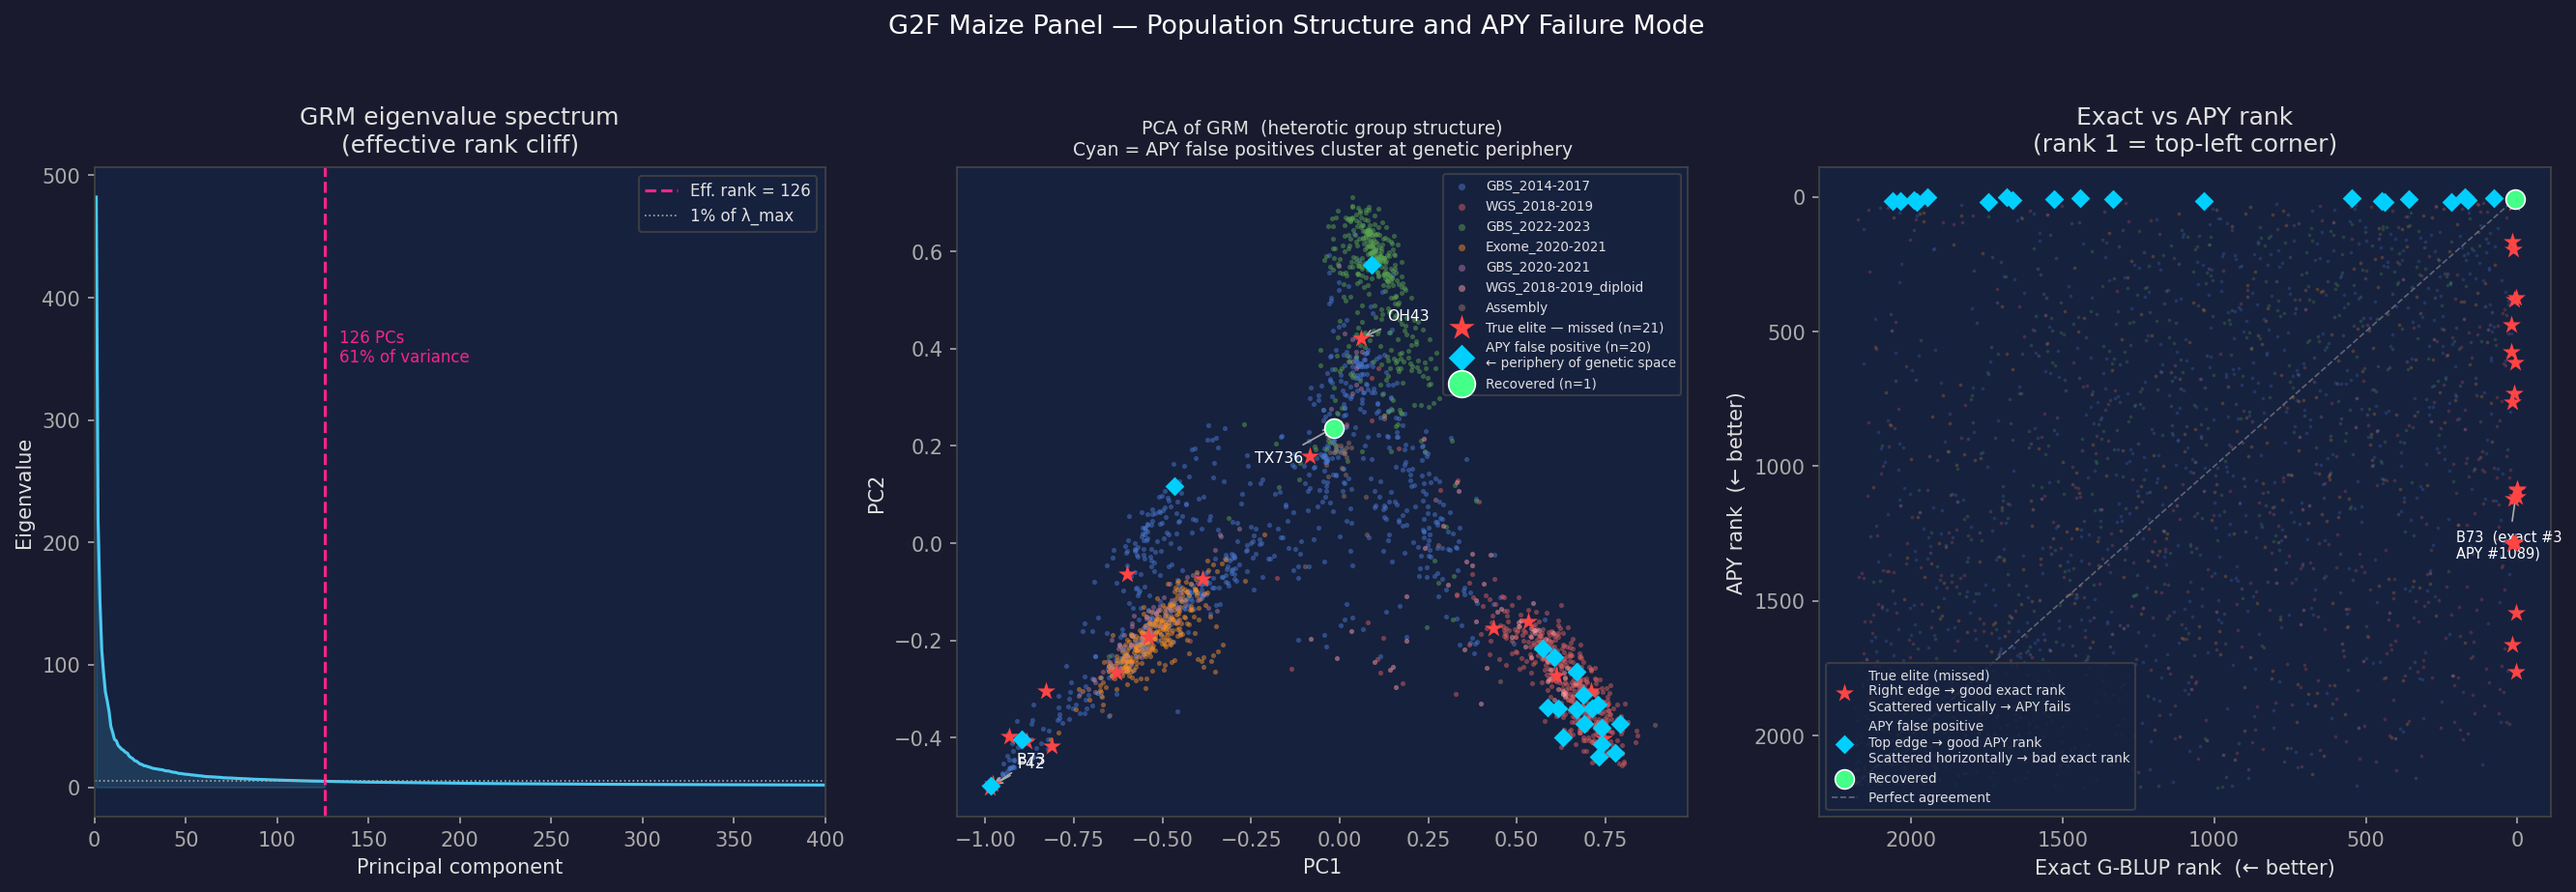

Saved: pca_apy_failure.png


In [84]:
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display as ipdisplay

# ── Eigendecomposition of GRM ──────────────────────────────────────────────────
print('Computing GRM eigendecomposition (N=2191) ...')
t0 = time.time()
eigvals_all, eigvecs_all = np.linalg.eigh(G)
eigvals = eigvals_all[::-1]
eigvecs = eigvecs_all[:, ::-1]
print(f'  done in {time.time()-t0:.1f}s')

eff_rank  = int(np.sum(eigvals > 0.01 * eigvals[0]))
var_top   = eigvals[:eff_rank].sum() / eigvals[eigvals > 0].sum()
print(f'  Effective rank (λ > 1% of λ_max):  {eff_rank}')
print(f'  Variance explained by top-{eff_rank} PCs:  {var_top:.1%}')

pc1 = eigvecs[:, 0] * np.sqrt(eigvals[0])
pc2 = eigvecs[:, 1] * np.sqrt(eigvals[1])
pc1_range = pc1.max() - pc1.min()
pc2_range = pc2.max() - pc2.min()

# ── Per-line metadata ─────────────────────────────────────────────────────────
ds_type    = np.array([key_dict.get(n, 'unknown') for n in names])
ex_rank_v  = np.array([exact_rank[n] for n in names])
apy_rank_v = np.array([apy_rank[n]   for n in names])
is_elite   = np.array([n in top_exact_names for n in names])
is_fp      = np.array([n in false_pos       for n in names])
is_recov   = np.array([n in recovered       for n in names])

ds_palette = {
    'GBS_2014-2017':        '#4878CF',
    'WGS_2018-2019':        '#D65F5F',
    'GBS_2022-2023':        '#59A14F',
    'Exome_2020-2021':      '#F28E2B',
    'GBS_2020-2021':        '#B07AA1',
    'WGS_2018-2019_diploid':'#FF9DA7',
    'Assembly':             '#9C755F',
    'unknown':              '#BAB0AC',
}

fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor('#1a1a2e')

# ── Panel 1: Scree plot ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)
ax1.set_facecolor('#16213e')
x_sc = np.arange(1, min(401, len(eigvals)+1))
ax1.plot(x_sc, eigvals[:400], color='#4cc9f0', lw=1.5)
ax1.axvline(eff_rank, color='#f72585', lw=1.5, ls='--', label=f'Eff. rank = {eff_rank}')
ax1.axhline(0.01 * eigvals[0], color='#aaa', lw=0.8, ls=':', label='1% of λ_max')
ax1.fill_between(x_sc[:eff_rank], eigvals[:eff_rank], alpha=0.15, color='#4cc9f0')
ax1.set_xlabel('Principal component', color='#e0e0e0')
ax1.set_ylabel('Eigenvalue', color='#e0e0e0')
ax1.set_title('GRM eigenvalue spectrum\n(effective rank cliff)', color='#e0e0e0', pad=8)
ax1.tick_params(colors='#aaa')
for sp in ax1.spines.values(): sp.set_color('#444')
ax1.legend(fontsize=8, facecolor='#16213e', labelcolor='#e0e0e0', edgecolor='#444')
ax1.set_xlim(0, 400)
ax1.text(eff_rank + 8, eigvals[0] * 0.72,
         f'{eff_rank} PCs\n{var_top:.0%} of variance',
         color='#f72585', fontsize=8)

# ── Panel 2: PCA ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)
ax2.set_facecolor('#16213e')
for ds, col in ds_palette.items():
    mask = (ds_type == ds) & ~is_elite & ~is_fp & ~is_recov
    if not mask.any(): continue
    ax2.scatter(pc1[mask], pc2[mask], c=col, s=6, alpha=0.5, label=ds, linewidths=0)
ax2.scatter(pc1[is_elite], pc2[is_elite], c='#ff4444', s=90, marker='*',
            zorder=5, label=f'True elite — missed (n={is_elite.sum()})', linewidths=0)
ax2.scatter(pc1[is_fp], pc2[is_fp], c='#00cfff', s=45, marker='D',
            zorder=5, label=f'APY false positive (n={is_fp.sum()})\n← periphery of genetic space', linewidths=0)
if is_recov.any():
    ax2.scatter(pc1[is_recov], pc2[is_recov], c='#44ff88', s=90, marker='o',
                zorder=5, label='Recovered (n=1)', lw=0.8, edgecolors='white')

# Labels with relative offsets
for label, dx, dy in [('B73',    0.04,  0.04),
                       ('TX736', -0.12, -0.06),
                       ('OH43',   0.04,  0.03),
                       ('F42',    0.04,  0.03)]:
    idx = name_to_idx.get(label)
    if idx is None: continue
    ax2.annotate(label, (pc1[idx], pc2[idx]),
                 xytext=(pc1[idx] + dx * pc1_range,
                         pc2[idx] + dy * pc2_range),
                 fontsize=7.5, color='white',
                 arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))
ax2.set_xlabel('PC1', color='#e0e0e0')
ax2.set_ylabel('PC2', color='#e0e0e0')
ax2.set_title('PCA of GRM  (heterotic group structure)\nCyan = APY false positives cluster at genetic periphery',
              color='#e0e0e0', pad=6, fontsize=9)
ax2.tick_params(colors='#aaa')
for sp in ax2.spines.values(): sp.set_color('#444')
ax2.legend(fontsize=6.5, facecolor='#16213e', labelcolor='#e0e0e0',
           edgecolor='#444', markerscale=1.4, loc='upper right')

# ── Panel 3: Rank scatter ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3)
ax3.set_facecolor('#16213e')
for ds, col in ds_palette.items():
    mask = (ds_type == ds) & ~is_elite & ~is_fp
    if not mask.any(): continue
    ax3.scatter(ex_rank_v[mask], apy_rank_v[mask], c=col, s=3, alpha=0.25, linewidths=0)
ax3.scatter(ex_rank_v[is_elite], apy_rank_v[is_elite], c='#ff4444', s=90,
            marker='*', zorder=5, label='True elite (missed)\nRight edge → good exact rank\nScattered vertically → APY fails', linewidths=0)
ax3.scatter(ex_rank_v[is_fp], apy_rank_v[is_fp], c='#00cfff', s=45,
            marker='D', zorder=5, label='APY false positive\nTop edge → good APY rank\nScattered horizontally → bad exact rank', linewidths=0)
if is_recov.any():
    ax3.scatter(ex_rank_v[is_recov], apy_rank_v[is_recov], c='#44ff88', s=90,
                marker='o', zorder=5, label='Recovered', lw=0.8, edgecolors='white')
ax3.plot([1, N], [1, N], color='#aaa', lw=0.8, ls='--', alpha=0.5, label='Perfect agreement')
ax3.invert_xaxis()
ax3.invert_yaxis()
b73i = name_to_idx.get('B73')
if b73i is not None:
    ax3.annotate('B73  (exact #3\nAPY #1089)',
                 (ex_rank_v[b73i], apy_rank_v[b73i]),
                 xytext=(ex_rank_v[b73i] + 200, apy_rank_v[b73i] + 250),
                 fontsize=7, color='white',
                 arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))
ax3.set_xlabel('Exact G-BLUP rank  (← better)', color='#e0e0e0')
ax3.set_ylabel('APY rank  (← better)', color='#e0e0e0')
ax3.set_title('Exact vs APY rank\n(rank 1 = top-left corner)', color='#e0e0e0', pad=8)
ax3.tick_params(colors='#aaa')
for sp in ax3.spines.values(): sp.set_color('#444')
ax3.legend(fontsize=6.5, facecolor='#16213e', labelcolor='#e0e0e0',
           edgecolor='#444', loc='lower left')

plt.suptitle('G2F Maize Panel — Population Structure and APY Failure Mode',
             color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('pca_apy_failure.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e', edgecolor='none')
plt.close()
ipdisplay(IPImage('pca_apy_failure.png'))
print('Saved: pca_apy_failure.png')
